# making custom transformers and changing on data 

# imports 


In [2]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
import matplotlib.pyplot as plt
from sklearn.ensemble import GradientBoostingClassifier
from lightgbm import LGBMClassifier
from sklearn.impute import SimpleImputer,KNNImputer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import category_encoders as ce
import joblib
import os
import json
import pickle
import pandas as pd 
import numpy as np 
from CustomTranformers.Custom_Transf import Preprocces \
, FullImputer , preproccesBeforePipe , try_diffrient_classification_models \
, GetDiffrentClassifiers , getting_counts ,getting_lat_long,get_best_match ,get_closest_address

In [3]:
from sklearn.ensemble import RandomForestClassifier,AdaBoostClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import ExtraTreesClassifier
# from sklearn.tree import DecisionTreeClassifier
# from sklearn.gaussian_process import GaussianProcessClassifier
# from sklearn.neighbors import KNeighborsClassifier
# from sklearn.svm import SVC
# from sklearn.gaussian_process.kernels import RBF
# from sklearn.naive_bayes import GaussianNB
# from sklearn.linear_model import SGDClassifier

In [4]:
# data = pd.read_csv('data/train.csv')

In [5]:
# data.dtypes

In [6]:
# data.isnull().sum()

# preproccesing before training 

In [7]:
# df_model = preproccesBeforePipe(data,train=True)

In [8]:
# df_model.to_csv('data/df_model.csv',index = False)

In [9]:
# df_model = pd.read_csv('data/df_model.csv')

# splitting the data and making stratify 

In [10]:
# X_train, X_test,y_train, y_test= train_test_split(df_model.drop('target',axis = 1),
#         df_model[['observation_id','target']],test_size = .2 ,random_state=42, stratify=df_model['target'])

In [11]:
# X_train , y_train = df_trian.drop('target',axis = 1) , df_trian['target']
# X_test , y_test = df_test.drop('target',axis = 1) , df_test[['target']]


        # for trianing on all data
# X_trainAll , y_trainAll = df_model.drop('target',axis = 1) , df_model[['observation_id','target']]

In [12]:
# X_trainAll.to_csv('data/X_trainAll.csv',index = False)
# y_trainAll.to_csv('data/y_trainAll.csv',index = False)

# saving the data files

In [13]:
# X_train.to_csv('data/low/X_trainLow.csv',index = False)
# y_train.to_csv('data/low/y_trainLow.csv',index = False)
# X_test.to_csv('data/low/X_testLow.csv',index = False)
# y_test.to_csv('data/low/y_testLow.csv',index = False)

In [ ]:
# getting data spliting 

In [ ]:
X_train = pd.read_csv('data/X_train.csv')
y_train = pd.read_csv('data/y_train.csv')
X_test = pd.read_csv('data/X_test.csv')
y_test = pd.read_csv('data/y_test.csv')

In [23]:
X_train = pd.read_csv('data/low/X_trainLow.csv')
y_train = pd.read_csv('data/low/y_trainLow.csv')
X_test = pd.read_csv('data/low/X_testLow.csv')
y_test = pd.read_csv('data/low/y_testLow.csv')

In [24]:
y_train['target'].value_counts()

False    267263
True      56321
Name: target, dtype: int64

In [16]:
# X_trainAll = pd.read_csv('data/X_trainAll.csv')
# y_trainAll = pd.read_csv('data/y_trainAll.csv')

# making Custom transformers

In [17]:
# They are in the custom_trnaf file 

In [18]:
# class Preprocces(BaseEstimator, TransformerMixin):
#     def __init__(self):
#         return None

#     def fit(self, X, y=None):
#         # Fit the transformer and store it.
#         return self
        
#     def transform(self, X):
#         df_model= X.copy()
# #         df_model = df_model.set_index('observation_id')
#         seasons = {
#     1: 'Winter',
#     2: 'Winter',
#     3: 'Spring',
#     4: 'Spring',
#     5: 'Spring',
#     6: 'Summer',
#     7: 'Summer',
#     8: 'Summer',
#     9: 'Fall',
#     10: 'Fall',
#     11: 'Fall',
#     12: 'Winter'
# }
        
#         # feature engineering from Date 
#         df_model['Date'] = pd.to_datetime(df_model['Date'],infer_datetime_format=True)
#         df_model['day_of_week'] = df_model['Date'].dt.day_name()
#         df_model['month'] = df_model['Date'].dt.month
#         df_model['hour'] = df_model['Date'].dt.hour
#         df_model['year'] = df_model['Date'].dt.year
#         df_model['day_of_month'] = df_model['Date'].dt.day
#         df_model['quarter'] = df_model['Date'].dt.quarter
#         df_model['week_of_year'] = df_model['Date'].dt.isocalendar().week
#         df_model['season'] = df_model['month'].map(seasons)
#         df_model['is_weekend'] = df_model['day_of_week'].isin([5, 6]).astype(int)
#         df_model.drop(columns = ['Date','observation_id'],inplace=True)
#         return df_model

In [ ]:
# class FullImputer(BaseEstimator, TransformerMixin):
#     def __init__(self):
#         return None

#     def fit(self, X, y=None):
#         data = X.copy()
#         # Fit the transformer and store it.
#         self.pipe = joblib.load('pickles/pipeline_legislation.pickle')
#         self.mapping = {}
#         for name, group in data.groupby("station")[['Latitude','Longitude']]:
#             try :
                
#                 self.mapping [name] = group.mode().iloc[0].to_dict()  
#             except IndexError : 
#                 continue
#         return self
        
#     def transform(self, X):
#         data = X.copy()
# #         # filling outcome linked
# #         data.loc[:,'Outcome linked to object of search'].fillna(False,inplace = True)
#         # filling part of policing operation
#         data['Part of a policing operation'].fillna(False,inplace = True)
#         # filling legislation 
#         test = data.loc[data['Legislation'].isnull(),['Legislation','Object of search']]
#         pred =  self.pipe.predict(test[['Object of search']])
#         data.loc[data['Legislation'].isnull(),'Legislation'] = pred
#         # filling lat and long 
#         for name, group in data.groupby("station")[['Latitude','Longitude']]:
#             try :
#                 idxs = group.index
#                 if group['Latitude'].isnull().sum() : 
#                     imputer_lat = SimpleImputer(strategy="constant",fill_value = self.mapping[name]['Latitude'])
#                     data.loc[idxs,['Latitude']] = imputer_lat.fit_transform(group[['Latitude']])
#                 if group['Longitude'].isnull().sum() :
#                     imputer_long = SimpleImputer(strategy="constant",fill_value = self.mapping[name]['Longitude'])
#                     data.loc[idxs,['Longitude']] = imputer_long.fit_transform(group[['Longitude']])
#             except KeyError :
#                 coordinate = getting_lat_long(name)
#                 for key , value in coordinate.items():
#                     imputer_fail = SimpleImputer(strategy='constant',fill_value=value)
#                     data.loc[idxs,[key]] = imputer_fail.fit_transform(group[[key]])
                
#         return data

# getting numerical and categorical features

In [25]:
# proccesor = Preprocces()
# imputer = FullImputer()
# temp = imputer.fit_transform(proccesor.fit_transform(X_train))
# numerical_features = list(temp.select_dtypes(['float64','int64']).columns)
# categorical_features = list(temp.select_dtypes(['bool','object']).columns)
# print(numerical_features)
# print(categorical_features)
numerical_features = ['Latitude', 'Longitude', 'month', 'hour', 'year']
categorical_features = ['Type', 'Part of a policing operation', 'Gender', 'Age range', 'Officer-defined ethnicity', 'Object of search', 'station']

In [20]:
# # additional features in 
# numerical_features = ['Latitude', 'Longitude', 'month', 'hour', 'year','quarter',
#     'week_of_year',
#     'day_of_month',
#     'is_weekend']
# categorical_features = ['Type', 'Part of a policing operation', 'Gender', 'Age range', 'Officer-defined ethnicity', 'Legislation', 'Object of search', 'station','season','day_of_week']

# making the full pipeline 

In [26]:

numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())])

categorical_transformer = Pipeline(steps=[
    ('onehot', ce.one_hot.OneHotEncoder(handle_unknown='indicator',use_cat_names=True))])

Dealer = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)])
Pipe = Pipeline([
    ('preprocces',Preprocces()),
    ('imputer',FullImputer())
    ,('dealer',Dealer)
    ,('model',LGBMClassifier(random_state=42,n_jobs=-1))
])


# checking dataframe shape 

# loading the display model 

In [ ]:
# Pipe = joblib.load('pickles/pipes/display_pipe2.pickle')

# training Display model

In [ ]:
# Pipe = Pipeline([
#     ('preprocces',Preprocces()),
#     ('imputer',FullImputer())
#     ,('dealer',Dealer)
# ])
# Pipe.fit(X_train)
# # temp = Pipe.transform(X_train)
# # temp = Pipe.transform(X_test)
# # joblib.dump(Pipe, 'pickles/pipes/display_pipe.pickle') 

In [ ]:
# get_best_match(None,[True,False])

# Display transformation

In [ ]:
# temp = Pipe.transform(X_train)
# encoded_cols = Pipe['dealer'].named_transformers_['cat']['onehot'].get_feature_names()
# pd.DataFrame(temp,columns=numerical_features+encoded_cols)

In [ ]:
# X_train.dtypes

# show distro

In [ ]:
y_train['target'].value_counts()

# Loading the model 

In [ ]:
Pipe = joblib.load('pickles/diffmodel/adv_pipe.pickle')

In [ ]:
Pipe

# Fitting the model

In [27]:
Pipe.fit(X_train,y_train['target'])

Pipeline(steps=[('preprocces', Preprocces()), ('imputer', FullImputer()),
                ('dealer',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['Latitude', 'Longitude',
                                                   'month', 'hour', 'year']),
                                                 ('cat',
                                                  Pipeline(steps=[('onehot',
                                                                   OneHotEncoder(handle_unknown='indicator',
                                                                                 use_cat_names=True))]),
                                                  ['Type',
                                                   'Part of a policing '
                                                   'operation',
                                                   'Gender', 'Age range',
                                                   'Officer-defined ethnicity',
                                                   'Object of search',
                                                   'station'])])),
                ('model', LGBMClassifier(random_state=42))])

In [30]:
from sklearn.metrics import precision_recall_curve, average_precision_score
from sklearn.metrics import precision_score, \
                            recall_score, f1_score, \
                            roc_auc_score, roc_curve, \
                            confusion_matrix , auc
y_pred_proba = Pipe.predict_proba(X_test)[:, 1]

    # Calculate average precision score
print(average_precision_score(y_test['target'],y_pred_proba))
print(roc_auc_score(y_test['target'],y_pred_proba))

0.301612760014569
0.7026968424181538


# feature importance 

In [ ]:
# importances[['month', 'hour', 'year','quarter',
#     'week_of_year',
#     'day_of_month',
#     'is_weekend']].sort_values(ascending=False)

In [ ]:
# categorical_encode_step = Pipe.named_steps['dealer'].named_transformers_['cat'].named_steps['onehot']
# model_step = Pipe.named_steps['model']

# onehot_columns = categorical_encode_step.get_feature_names()

# importances = pd.Series(data=model_step.feature_importances_, index = np.array(numerical_features + list(onehot_columns)))
# indices = np.argsort(importances)[::-1]
# print("Feature ranking:")

# for f in range(len(importances)):
#     print("%d. feature %s (%f)" % (f + 1, importances.index[indices[f]], importances[indices[f]]))


# plt.figure()
# plt.title("Feature importances")
# plt.bar(x=importances.index[indices], height=importances[indices],
#         color="r", align="center");
# plt.xticks(range(len(importances.index[indices])), importances.index[indices], rotation=45, ha="right")
# plt.xlim([-1, X_train.shape[1]])
# plt.xlabel('Features');
# plt.ylabel('Importance');

# plt.show()


# Trying GridSearch

In [ ]:
# from sklearn.model_selection import RandomizedSearchCV
# from sklearn.model_selection import ParameterSampler
# # define the hyperparameters to search over
# hyperparameters = {
#     'model__learning_rate': [0.01, 0.05, 0.1, 0.2],  # learning rate for the GradientBoostingClassifier
#     'model__n_estimators': [50, 100, 200, 400],  # number of trees for the GradientBoostingClassifier
#     'model__max_depth': [3, 4, 5, 6],  # maximum depth of each tree for the GradientBoostingClassifier
#     'model__min_samples_split': [2, 4, 8],  # minimum number of samples required to split an internal node
#     'model__min_samples_leaf': [1, 2, 4]  # minimum number of samples required to be at a leaf node
# }
# random_search = RandomizedSearchCV(Pipe, hyperparameters,n_iter=400, cv=2, n_jobs=-1,scoring='roc_auc',verbose=1)
# random_search.fit(X_trainAll,y_trainAll['target'])

# best = random_search.best_estimator_
# joblib.dump(Pipe, 'pickles/diffmodel/Date_features_pipe.pickle') 

In [ ]:
# from sklearn.model_selection import RandomizedSearchCV
# from sklearn.pipeline import Pipeline
# from sklearn.ensemble import GradientBoostingClassifier
# from sklearn.metrics import make_scorer, average_precision_score
# from scipy.stats import randint as sp_randint

# # Define the pipeline

# # Define the parameter grid for random search
# param_grid = {
#     'model__n_estimators': sp_randint(100, 1000),
#     'model__learning_rate': [0.1, 0.01, 0.001],
#     'model__max_depth': sp_randint(3, 10)
# }

# # Define the average precision scorer
# avg_precision_scorer = make_scorer(average_precision_score, greater_is_better=True)

# # Perform random search with 100 iterations using average precision as the scoring metric
# random_search = RandomizedSearchCV(Pipe, param_distributions=param_grid, n_iter=100, scoring=avg_precision_scorer, random_state=42)
# random_search.fit(X_train,y_train['target'])

# # Get the best estimator and its average precision score
# best_estimator = random_search.best_estimator_
# best_avg_precision = random_search.best_score_

# # Print the best estimator and its average precision score
# print("Best Estimator:", best_estimator)
# print("Best Average Precision Score:", best_avg_precision)


In [ ]:
# from sklearn.model_selection import ParameterSampler
# from tqdm.notebook import tqdm
# from sklearn.metrics import precision_recall_curve, f1_score
# # define the hyperparameters to search over

# hyperparameters = {
#     'learning_rate': [0.01, 0.05, 0.1, 0.2],  # learning rate for the GradientBoostingClassifier
#     'n_estimators': [50, 100, 200, 400],  # number of trees for the GradientBoostingClassifier
#     'max_depth': [3, 4, 5, 6],  # maximum depth of each tree for the GradientBoostingClassifier
#     'min_samples_split': [2, 4, 8],  # minimum number of samples required to split an internal node
#     'min_samples_leaf': [1, 2, 4]  # minimum number of samples required to be at a leaf node
# }
# best_recall = .70
# best_perc = .3
# best_Pipe = None
# for x in ParameterSampler(hyperparameters,100):
#     clf = GradientBoostingClassifier(**x)
#     Pipe = Pipeline([
#     ('preprocces',Preprocces()),
#     ('imputer',FullImputer())
#     ,('dealer',Dealer)
#     ,('model',clf)
# ])
#     Pipe.fit(X_train,y_train['target'])

#     pred_proba = Pipe.predict_proba(X_test)[:, 1]
#     precisions, recalls, thresholds = precision_recall_curve(y_test['target'], pred_proba)
#     precisions = precisions[:-1]
#     recalls = recalls[:-1]
# # f1_scores = 2*(precision*recall)/(precision + recall)
#     min_index = [i for i, rec in enumerate(recalls) if rec >= best_recall][-1]
#     recall = recalls[min_index]
#     precision = precisions[min_index]
#     threshold = thresholds[min_index]
#     if precision> best_perc:
#         best_Pipe = Pipe
#         best_perc = precision
#         params = Pipe.named_steps['model']
#         print(f'the best we got with precision {best_perc} and recall{recall} and threshold {threshold}and with paramters{params}')

In [ ]:
# Pipe = best_Pipe

# Get categories values

In [ ]:
# categories_values = {}

# for col in [x for x in X_train.columns if x not in ['observation_id', 'Date', 'Longitude', 'Latitude','Part of a policing operation']]:
    
#     unique_values = X_train[col].unique().tolist()
#     categories_values[col] = unique_values
    

# with open('pickles/categories_values.json', 'w') as fh:
#     json.dump(categories_values, fh)

# save pickles

In [34]:
# # saving the pipeline and columns and dtypes and boundries
# boudries_of_numric = {
#     col: {
#         'max': df_model[col].max(),
#         'min': df_model[col].min()
#     }
#     for col in ['Longitude','Latitude']
# }
# boudries_of_numric
# with open('pickles/boundriesOfNumeric.json', 'w') as fh:
#     json.dump(boudries_of_numric, fh)

# with open('pickles/columns.json', 'w') as fh:
#     json.dump(X_train.columns.tolist(), fh)
# with open('pickles/dtypes.pickle', 'wb') as fh:
#     pickle.dump(X_train.dtypes, fh)
joblib.dump(Pipe, 'pickles/diffmodel/randomtry.pickle') 

['pickles/diffmodel/randomtry.pickle']

# trying on single raw with unknown value

In [ ]:
# tr = X_test.iloc[[0]].copy()
# tr['station'] = 'main'


# pred_proba = Pipe.predict_proba(tr)[0, 1]
# pred_proba
# preds = [1 if pred > threshold else 0 for pred in pred_proba ]

# predicting test

In [40]:
Pipe = joblib.load('pickles/diffmodel/bestPipe.pickle')

In [41]:
Pipe

Pipeline(steps=[('preprocces', Preprocces()), ('imputer', FullImputer()),
                ('dealer',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['Latitude', 'Longitude',
                                                   'month', 'hour', 'year']),
                                                 ('cat',
                                                  Pipeline(steps=[('onehot',
                                                                   OneHotEncoder(handle_unknown='indicator',
                                                                                 use_cat_names=True))]),
                                                  ['Type',
                                                   'Part of a policing '
                                                   'operation',
                                                   'Gender', 'Age range',
                                                   'Officer-defined ethnicity',
                                                   'Legislation',
                                                   'Object of search',
                                                   'station'])])),
                ('model',
                 LGBMClassifier(learning_rate=0.3, n_estimators=700,
                                random_state=42))])

In [42]:
       # make this threshold the perfom only the searches more than 0.1 succes probability
pred_proba = Pipe.predict_proba(X_test)[:, 1]

# getting best threshold

In [ ]:
# X_testLow = pd.read_csv('data/low/X_testLow.csv')
# y_testLow = pd.read_csv('data/low/y_testLow.csv')

/tmp/ipykernel_895/4064803878.py:6: RuntimeWarning: invalid value encountered in true_divide
  f1_scores = 2*(precision*recall)/(precision + recall)
/tmp/ipykernel_895/4064803878.py:24: MatplotlibDeprecationWarning: The join function was deprecated in Matplotlib 3.6 and will be removed two minor releases later.
  ax1.get_shared_x_axes().join(ax1, ax2,ax3)


recall : 0.65
precision : 0.2866090442189653
threshold : 0.29041924768842275
f1 score : 0.3978092671477006


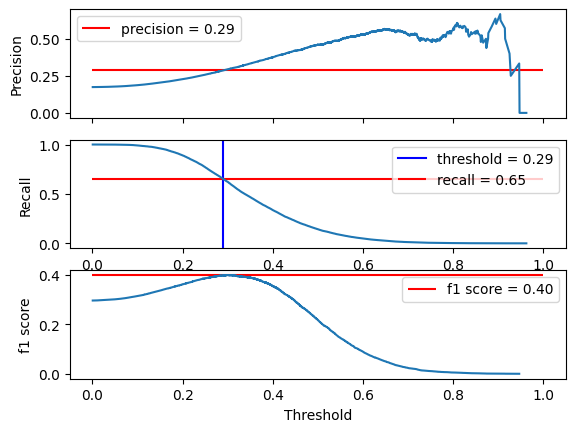

In [43]:
from sklearn.metrics import precision_recall_curve, f1_score

precision, recall, thresholds = precision_recall_curve(y_test['target'], pred_proba)
precision = precision[:-1]
recall = recall[:-1]
f1_scores = 2*(precision*recall)/(precision + recall)
maxf = max(f1_scores)
min_index = [i for i, rec in enumerate(recall) if rec >= 0.65][-1]
print(f'recall : {recall[min_index]}')
print(f'precision : {precision[min_index]}')
print(f'threshold : {thresholds[min_index]}')
print(f'f1 score : {f1_scores[min_index]}')
fig=plt.figure()
ax1 = plt.subplot(311)
ax2 = plt.subplot(312)
ax3 = plt.subplot(313)
ax1.hlines(y=precision[min_index],xmin=0, xmax=1, colors='red', label=f'precision = {precision[min_index]:.2f}')
ax2.axvline(thresholds[min_index], color='blue', label=f'threshold = {thresholds[min_index]:.2f}')
ax2.hlines(y=recall[min_index],xmin=0, xmax=1, colors='red', label=f'recall = {recall[min_index]:.2f}')
ax3.hlines(y=f1_scores[min_index],xmin=0, xmax=1, colors='red', label=f'f1 score = {f1_scores[min_index]:.2f}')
ax1.plot(thresholds,precision)
ax2.plot(thresholds,recall)
ax3.plot(thresholds,f1_scores)
ax1.get_shared_x_axes().join(ax1, ax2,ax3)
ax1.set_xticklabels([])
ax1.set_ylabel('Precision')
ax2.set_ylabel('Recall')
ax1.legend(loc='best')
ax2.legend(loc='best')
ax3.legend(loc='best')
ax3.set_ylabel('f1 score')
plt.xlabel('Threshold')
plt.show()


In [35]:
threshold = 0.2583720212736386
preds = [1 if pred > threshold else 0 for pred in pred_proba ]

In [36]:
from sklearn.metrics import precision_score, recall_score
precision = precision_score(y_test['target'],preds)
recall = recall_score(y_test['target'],preds)
f1 = f1_score(y_test['target'],preds)

# Print the F1 score
print("F1 score:", f1)
print(f'precision = {precision}')
print(f'recall = {recall}')

F1 score: 0.3434586270751438
precision = 0.3165079935333214
recall = 0.37542613636363636


# Evaluate model 

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
plt.figure(figsize = (2,4)) # <-- just sets the figure size 
confmat = confusion_matrix(y_true=y_test['target'], y_pred=preds)
disp = ConfusionMatrixDisplay(confusion_matrix=confmat,
                               display_labels=Pipe.classes_)

fig, ax = plt.subplots(figsize=(8, 8))
im = disp.plot(ax=ax, cmap=plt.cm.Blues, values_format='d')

# add annotations to each square
for i in range(confmat.shape[0]):
    for j in range(confmat.shape[1]):
        ax.text(j, i, f"\n{confmat[i, j]:d}\n"
                       f"{'True Negative' if i == j and i==0 else 'True Posative' if i== j and i ==1 else 'False Posative' if j > i else 'False Negative'}",
                ha="center", va="center", color="white" if confmat[i, j] > confmat.max() / 2 else "black")
plt.savefig('pics/confmat.png')
plt.show()

In [ ]:
from sklearn.metrics import precision_score, \
                            recall_score, f1_score, \
                            roc_auc_score, roc_curve, \
                            confusion_matrix , auc
fpr, tpr, threshold = roc_curve(y_test['target'],pred_proba)
roc_auc = auc(fpr, tpr)

plt.title('Receiver Operating Characteristic')
plt.plot(fpr, tpr, 'b', label = 'AUC = %0.2f' % roc_auc)
plt.legend(loc = 'lower right')
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
print("Score: "+ str(roc_auc))
plt.show()

# average precision

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score

# Assuming you have true labels and predicted probabilities

# Compute precision and recall values
precision, recall, _ = precision_recall_curve(y_test['target'],pred_proba)

# Calculate average precision
ap = average_precision_score(y_test['target'],pred_proba)

# Plot precision-recall curve
plt.step(recall, precision, color='b', alpha=0.2, where='post')
plt.fill_between(recall, precision, step='post', alpha=0.2, color='b')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve (AP={:.2f})'.format(ap))
plt.ylim([0.0, 1.05])
plt.xlim([0.0, 1.0])
plt.show()

print('Average Precision: {:.2f}'.format(ap))


# using auc

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, auc

# Assuming you have true labels and predicted probabilities
y_true = [0, 1, 1, 0, 1]
y_scores = [0.2, 0.6, 0.8, 0.3, 0.9]

# Compute precision and recall values
precision, recall, _ = precision_recall_curve(y_test['target'],pred_proba)

# Calculate area under precision-recall curve (average precision)
average_precision = auc(recall, precision)

# Plot precision-recall curve
plt.plot(recall, precision, color='b', label='Precision-Recall curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve (AP = {:.2f})'.format(average_precision))
plt.ylim([0.0, 1.05])
plt.xlim([0.0, 1.0])
plt.legend(loc='lower left')
plt.show()

print('Average Precision: {:.2f}'.format(average_precision))


# F1 score 

In [ ]:
from sklearn.metrics import f1_score

f1 = f1_score(y_test['target'],preds)

# Print the F1 score
print("F1 score:", f1)


# verify no discrimination

In [ ]:
def verify_no_discrimination( X_test, y_true, y_pred, max_diff_tuple=0.05,max_diff_stations = .1 ,min_samples=30):
    """
    Verifies that no subdeparment has discrimination in between protected races
    """
    stations = X_test['station'].unique()
    gender_classes = X_test['Gender'].unique()
    ethnicity_classes = X_test['Officer-defined ethnicity'].unique()
    
    is_satisfied_tuple = True
    is_satisfied_stations = True
    problematic_stations = {}
    good_stations = {}
    ignored_stations = {}
    ignored_subgroups = []
    global_succes_rate = {}
    for station in stations:
        success_rates = {}
        for gender_class in gender_classes:
            for ethnicity_class in ethnicity_classes :
                mask = (X_test['Gender'] == gender_class) & (X_test['station'] == station) & (X_test['Officer-defined ethnicity'] == ethnicity_class)
                
                if np.sum(mask) > min_samples:
                    try :
                        rate = precision_score(y_true[mask], y_pred[mask], pos_label=1, zero_division=0)
                        if rate < .01:
                            ignored_subgroups.append((station,gender_class,ethnicity_class))
                            continue
                        success_rates[(gender_class,ethnicity_class)] = ( rate, np.sum(mask))
                    except ZeroDivisionError : 
                        print(station)
                        print(data[mask].isnull().sum())
        if len(success_rates) > 1:    
            diff = np.max(list(x[0] for x in success_rates.values())) - np.min(list(x[0] for x in success_rates.values()))
            global_succes_rate[station] = np.mean(list(x[0] for x in success_rates.values()))
            if diff > max_diff_tuple:
                is_satisfied_tuple = False
                problematic_stations[station]= (diff, success_rates)
            else:
                good_stations[station] =( diff, success_rates)
        else:
            ignored_stations[station]= (None, [])
        
    global_desparncey_score = np.max(list(global_succes_rate.values())) - np.min(list(global_succes_rate.values()))
    if global_desparncey_score > max_diff_stations:
        is_satisfied_stations = False
        
    return is_satisfied_tuple,is_satisfied_stations, problematic_stations, good_stations, global_desparncey_score,global_succes_rate,ignored_stations,ignored_subgroups



In [ ]:
# def getting_counts(data,col_index , col_columns ):
#     cop = data.copy()
#     cop[col_index] =  cop[col_index].astype(str)
#     group = cop.groupby([col_index, 
#                 col_columns]).count()['observation_id'].unstack()
    
#     stations_that_all_nulls = [x for x in cop[col_index].unique() if x not in group.index]
#     second  =cop[data[col_columns].isnull()][col_index].value_counts()
#     group['missing'] = np.nan
    
#     for id in stations_that_all_nulls:
#         group.loc[id] = np.nan
#     group.loc[second.index,'missing'] =  second.values
# #     return group 
#     return round(group.div(group.sum(axis=1 ), axis=0),3).fillna(0)

In [ ]:
# getting_counts(pd.merge(X_test,y_test),'station','target')

In [ ]:
Pipe

In [ ]:
is_satisfied_tuple,is_satisfied_stations, problematic_stations, good_stations, global_desparncey_score,global_succes_rate,ignored_stations,ignored_subgroups = verify_no_discrimination(
    X_test, y_test['target'], pd.Series(preds),max_diff_tuple=.05,min_samples=100)

In [ ]:
if not is_satisfied_tuple:
    print("Requirement failed 😢")
    print("Global rates: {}".format(global_desparncey_score))
    print("Num problematic departments: {}".format(len(problematic_stations)))
    print("Num good departments: {}".format(len(good_stations)))
    print("Num ignored departments: {} and it's {}".format(len(ignored_stations),ignored_stations))
    print("avg diff:", np.mean([p[0] for p in problematic_stations.values()]))
else:
    print("Requirement satisfied! 🚀")

print("Departments analysed: {}".format(len(problematic_stations) + len(good_stations)))        

In [ ]:
problematic_stations

# Trying different models 

In [ ]:
Pipe.named_steps['model'].n_features_in_

In [ ]:
# try_diffrient_classification_models(X_train,y_train['target'],X_test,y_test['target'])

In [ ]:
# GetDiffrentClassifiers(X_train,y_train['target'],X_test,y_test['target'])